In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_data.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (97564, 3)
   User_ID        Age      Score
0        1  34.967142  65.458919
1        2  28.617357  32.669678
2        3  36.476885  58.631558
3        4  45.230299  40.711423
4        5  27.658466  45.088958


In [2]:

import holidays

dates = pd.date_range('2023-01-01', periods=len(df), freq='D')
df['date'] = dates
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

us_holidays = holidays.US(years=[2023, 2024, 2025])
df['is_holiday'] = df['date'].dt.date.map(lambda x: 1 if x in us_holidays else 0)

df['age_group'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100],
                          labels=['Young', 'Mid', 'Senior', 'Elder'])
df = pd.get_dummies(df, columns=['age_group'], prefix='age', dtype=int)

print("New shape:", df.shape)
print(df.head())

New shape: (97564, 12)
   User_ID        Age      Score       date  day_of_week  month  is_weekend  \
0        1  34.967142  65.458919 2023-01-01            6      1           1   
1        2  28.617357  32.669678 2023-01-02            0      1           0   
2        3  36.476885  58.631558 2023-01-03            1      1           0   
3        4  45.230299  40.711423 2023-01-04            2      1           0   
4        5  27.658466  45.088958 2023-01-05            3      1           0   

   is_holiday  age_Young  age_Mid  age_Senior  age_Elder  
0           1          0        1           0          0  
1           1          0        1           0          0  
2           0          0        0           1          0  
3           0          0        0           1          0  
4           0          0        1           0          0  


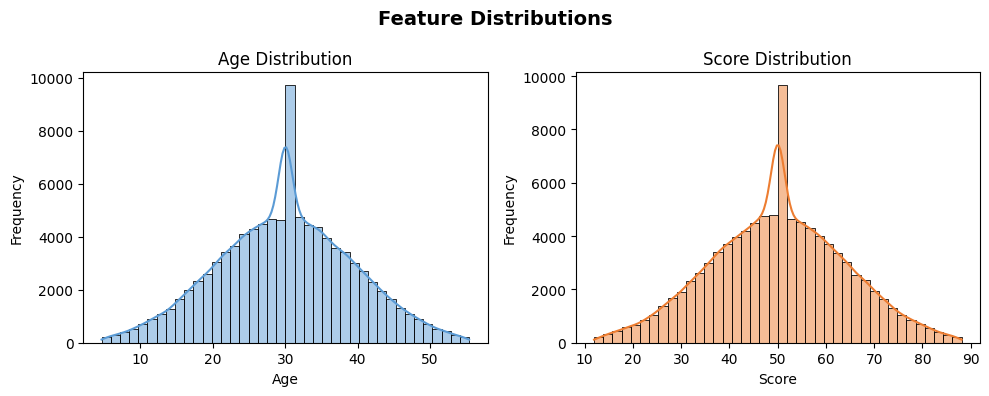

In [3]:

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=40, color='#5B9BD5', kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Score'], bins=40, color='#ED7D31', kde=True)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

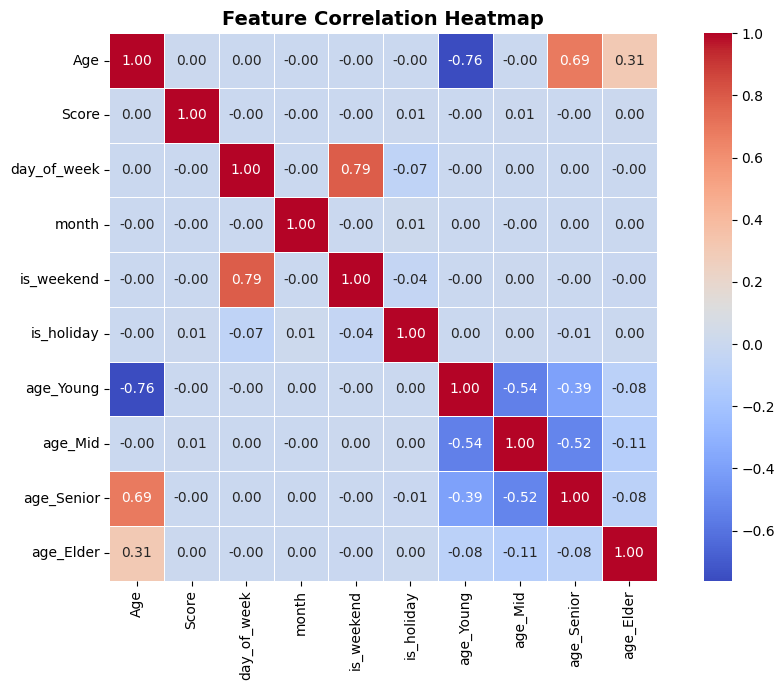

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df[['Age', 'Score', 'day_of_week', 'month', 'is_weekend', 
           'is_holiday', 'age_Young', 'age_Mid', 'age_Senior', 'age_Elder']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Export final dataset
df.drop(columns=['date'], inplace=True)
df.to_csv('features_v1.csv', index=False)
print("Saved features_v1.csv with shape:", df.shape)

Saved features_v1.csv with shape: (97564, 11)
